# PyTorch Training & Evaluation Notebook
Dual-Channel CNN–LSTM (MFCC + Chroma)

This notebook extends the pure TF→PyTorch model translation with a full training / testing / validation workflow: early stopping, checkpoints, LR scheduling, metrics, plots, and confusion matrix.

**Expected inputs** (NumPy arrays):
- `X_mfcc`: shape `[N, 40, 679]`
- `X_chroma`: shape `[N, 12, 259]`
- `y`: integer labels shape `[N]` (0..C-1)


## 1) Imports & Reproducibility

In [1]:
import os
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# -----------------------
# Reproducibility
# -----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2) Data Loading (replace with your feature files)
If you already have train/test/val splits saved, load them here.
A common approach is to store arrays in a single `.npz` file.

In [2]:
import numpy as np
import pandas as pd
import librosa as lb

# -----------------------------------
# Paths
# -----------------------------------
BASE_DIR = "../../dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train-segments")
TEST_DIR = os.path.join(BASE_DIR, "test-segments")
VAL_DIR = os.path.join(BASE_DIR, "val-segments")

TRAIN_CSV = os.path.join(BASE_DIR, "train_segments.csv")
TEST_CSV = os.path.join(BASE_DIR, "test_segments.csv")
VAL_CSV = os.path.join(BASE_DIR, "val_segments.csv")

# -----------------------------------
# Feature parameters
# -----------------------------------
SR = 4000
N_MFCC = 40
TARGET_MFCC_T = 679
TARGET_CHROMA_T = 259

In [3]:
def extract_mfcc_and_chroma(y, sr):
    mfcc = lb.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    chroma = lb.feature.chroma_stft(y=y, sr=sr)
    return mfcc, chroma


def pad_or_crop(feat, target_T):
    F, T = feat.shape

    if T > target_T:
        return feat[:, :target_T]

    if T < target_T:
        pad_width = target_T - T
        return np.pad(feat, ((0, 0), (0, pad_width)), mode="constant")

    return feat


In [4]:
def build_features_from_csv(csv_path, audio_dir):
    df = pd.read_csv(csv_path)

    mfcc_list = []
    chroma_list = []
    labels = []

    # Create consistent label mapping
    diseases = sorted(df["disease"].unique())
    label_map = {d: i for i, d in enumerate(diseases)}

    for _, row in df.iterrows():
        filename = os.path.basename(row["segment_file"])
        label = row["disease"]

        file_path = os.path.join(audio_dir, filename)

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Missing file: {file_path}")

        # Load audio
        y, sr = lb.load(file_path, sr=SR)

        # Extract features
        mfcc, chroma = extract_mfcc_and_chroma(y, sr)

        # Pad / crop
        mfcc = pad_or_crop(mfcc, TARGET_MFCC_T)
        chroma = pad_or_crop(chroma, TARGET_CHROMA_T)

        mfcc_list.append(mfcc)
        chroma_list.append(chroma)
        labels.append(label_map[label])

    X_mfcc = np.stack(mfcc_list)
    X_chroma = np.stack(chroma_list)
    y = np.array(labels)

    return X_mfcc, X_chroma, y, label_map


In [5]:
X_mfcc_train, X_chroma_train, y_train, label_map = build_features_from_csv(
    TRAIN_CSV, TRAIN_DIR
)

X_mfcc_test, X_chroma_test, y_test, _ = build_features_from_csv(
    TEST_CSV, TEST_DIR
)

X_mfcc_val, X_chroma_val, y_val, _ = build_features_from_csv(
    VAL_CSV, VAL_DIR
)


/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [6]:
X_mfcc_train = torch.from_numpy(X_mfcc_train).float()
X_chroma_train = torch.from_numpy(X_chroma_train).float()
y_train = torch.from_numpy(y_train).long()

X_mfcc_test = torch.from_numpy(X_mfcc_test).float()
X_chroma_test = torch.from_numpy(X_chroma_test).float()
y_test = torch.from_numpy(y_test).long()

X_mfcc_unseen = torch.from_numpy(X_mfcc_val).float()
X_chroma_unseen = torch.from_numpy(X_chroma_val).float()
y_unseen = torch.from_numpy(y_val).long()


In [7]:
# ------------------------------------------------------------
# (PLACEHOLDER) MFCC & Chroma extraction
# Your classmate will implement the real extraction pipeline here.
# This scaffold shows the expected inputs/outputs for the model.
# ------------------------------------------------------------
# Expected model inputs:
#   mfcc:   torch.FloatTensor [B, 40, 679]
#   chroma: torch.FloatTensor [B, 12, 259]
#
# Notes:
# - In your final pipeline, you will likely:
#   1) load audio (already resampled/filtered/segmented/normalized)
#   2) extract MFCC and chroma per 3-second segment
#   3) pad/crop along time axis to fixed lengths (679 and 259 here)
#
# If librosa is available, this is a minimal template:
#
# import librosa as lb
# import numpy as np
#
# def extract_mfcc_and_chroma(y: np.ndarray, sr: int):
#     # MFCC: shape [n_mfcc, T_mfcc]
#     mfcc = lb.feature.mfcc(y=y, sr=sr, n_mfcc=40)
#     # Chroma: shape [12, T_chr]
#     chroma = lb.feature.chroma_stft(y=y, sr=sr)
#     return mfcc, chroma
#
# def pad_or_crop(feat: np.ndarray, target_T: int):
#     # feat: [F, T]
#     F, T = feat.shape
#     if T == target_T:
#         return feat
#     if T > target_T:
#         return feat[:, :target_T]
#     # pad on the right
#     pad_width = target_T - T
#     return np.pad(feat, ((0,0),(0,pad_width)), mode="constant")
#
# In the dataloader, convert to torch:
#   mfcc = torch.from_numpy(mfcc).float()
#   chroma = torch.from_numpy(chroma).float()

In [8]:
# Example loader (edit paths / keys to match your pipeline)
# data = np.load("features_splits.npz", allow_pickle=True)
# X_mfcc_train = data["X_mfcc_train"]     # [N, 40, 679]
# X_chroma_train = data["X_chroma_train"] # [N, 12, 259]
# y_train = data["y_train"]               # [N]
# X_mfcc_test = data["X_mfcc_test"]
# X_chroma_test = data["X_chroma_test"]
# y_test = data["y_test"]
# X_mfcc_unseen = data["X_mfcc_unseen"]
# X_chroma_unseen = data["X_chroma_unseen"]
# y_unseen = data["y_unseen"]

# -----------------------
# TEMP: dummy data (delete once you load real arrays)
# -----------------------
num_classes = 6
N_train, N_test, N_unseen = 256, 64, 64

# X_mfcc_train = np.random.randn(N_train, 40, 679).astype(np.float32)
# X_chroma_train = np.random.randn(N_train, 12, 259).astype(np.float32)
# y_train = np.random.randint(0, num_classes, size=(N_train,)).astype(np.int64)

# X_mfcc_test = np.random.randn(N_test, 40, 679).astype(np.float32)
# X_chroma_test = np.random.randn(N_test, 12, 259).astype(np.float32)
# y_test = np.random.randint(0, num_classes, size=(N_test,)).astype(np.int64)

# X_mfcc_unseen = np.random.randn(N_unseen, 40, 679).astype(np.float32)
# X_chroma_unseen = np.random.randn(N_unseen, 12, 259).astype(np.float32)
# y_unseen = np.random.randint(0, num_classes, size=(N_unseen,)).astype(np.int64)

print("Train:", X_mfcc_train.shape, X_chroma_train.shape, y_train.shape)
print("Test: ", X_mfcc_test.shape, X_chroma_test.shape, y_test.shape)
print("Unseen:", X_mfcc_unseen.shape, X_chroma_unseen.shape, y_unseen.shape)

Train: torch.Size([3000, 40, 679]) torch.Size([3000, 12, 259]) torch.Size([3000])
Test:  torch.Size([3000, 40, 679]) torch.Size([3000, 12, 259]) torch.Size([3000])
Unseen: torch.Size([3000, 40, 679]) torch.Size([3000, 12, 259]) torch.Size([3000])


## 3) Dataset & DataLoader

In [9]:
class DualFeatureDataset(Dataset):
    def __init__(self, X_mfcc: np.ndarray, X_chroma: np.ndarray, y: np.ndarray):
        assert len(X_mfcc) == len(X_chroma) == len(y)
        self.X_mfcc = X_mfcc
        self.X_chroma = X_chroma
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_mfcc[idx],
            self.X_chroma[idx],
            self.y[idx]
        )

batch_size = 32

train_loader = DataLoader(DualFeatureDataset(X_mfcc_train, X_chroma_train, y_train),
                          batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

test_loader = DataLoader(DualFeatureDataset(X_mfcc_test, X_chroma_test, y_test),
                         batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

unseen_loader = DataLoader(DualFeatureDataset(X_mfcc_unseen, X_chroma_unseen, y_unseen),
                           batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

## 4) Model Definition (pure translation)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GatedFusion(nn.Module):
    """Lightweight attention fusion (gated mixture) for two feature vectors.

    Given a,b: [B, D]
      w = sigmoid(MLP([a;b])) in (0,1)  -> [B, D]
      fused = w*a + (1-w)*b
    """
    def __init__(self, dim: int, hidden: int = 128, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
        )

    def forward(self, a: torch.Tensor, b: torch.Tensor):
        w = torch.sigmoid(self.net(torch.cat([a, b], dim=1)))  # [B, D]
        fused = w * a + (1.0 - w) * b
        return fused, w


class DualChannelCNNLSTM_WithAttentionFusion(nn.Module):
    """Same CNN/LSTM branches as the TF translation, but with attention fusion:

    INTRA (cross-modality, per extractor):
      - CNN_fused  = fuse(MFCC_CNN,  CHROMA_CNN)
      - LSTM_fused = fuse(MFCC_LSTM, CHROMA_LSTM)

    INTER (cross-extractor):
      - final_fused = fuse(CNN_fused, LSTM_fused)

    Notes:
      - CNN feature maps are converted to vectors via AdaptiveAvgPool2d((1,1)) ("global average pooling").
      - This avoids the huge Flatten -> Dense parameter explosion from the original model.
    """

    def __init__(self, num_classes: int = 8, dropout_p: float = 0.4, fuse_dim: int = 64):
        super().__init__()
        self.fuse_dim = fuse_dim

        # -------------------------------
        # MFCC CNN path (input as [B,1,40,679])
        # -------------------------------
        self.mfcc_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),
        )

        # -------------------------------
        # CHROMA CNN path (input as [B,1,12,259])
        # -------------------------------
        self.chroma_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2),
        )

        # Global Average Pooling for CNN maps -> [B, 128]
        self.gap2d = nn.AdaptiveAvgPool2d((1, 1))

        # Project pooled CNN vectors (128) -> fuse_dim
        self.mfcc_cnn_proj = nn.Linear(128, fuse_dim)
        self.chroma_cnn_proj = nn.Linear(128, fuse_dim)

        # -------------------------------
        # MFCC LSTM path (TF: reshape to [B,679,40])
        # -------------------------------
        self.mfcc_lstm1 = nn.LSTM(input_size=40, hidden_size=128, batch_first=True)
        self.mfcc_lstm2 = nn.LSTM(input_size=128, hidden_size=fuse_dim, batch_first=True)

        # -------------------------------
        # CHROMA LSTM path (TF: reshape to [B,259,12])
        # -------------------------------
        self.chroma_lstm1 = nn.LSTM(input_size=12, hidden_size=128, batch_first=True)
        self.chroma_lstm2  = nn.LSTM(input_size=128, hidden_size=fuse_dim, batch_first=True)

        # -------------------------------
        # Fusion blocks (your requested order)
        # -------------------------------
        self.fuse_cnn_modality = GatedFusion(dim=fuse_dim, hidden=128, dropout=0.1)
        self.fuse_lstm_modality = GatedFusion(dim=fuse_dim, hidden=128, dropout=0.1)
        self.fuse_extractor = GatedFusion(dim=fuse_dim, hidden=128, dropout=0.1)

        # -------------------------------
        # Classifier head
        # -------------------------------
        self.fc1 = nn.Linear(fuse_dim, 128)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, mfcc: torch.Tensor, chroma: torch.Tensor, return_attn: bool = False):
        """mfcc: [B, 40, 679], chroma: [B, 12, 259] -> logits: [B, C]"""

        # -------------------------------
        # MFCC CNN -> pooled vector
        # -------------------------------
        mfcc_cnn_in = mfcc.unsqueeze(1)                 # [B, 1, 40, 679]
        mfcc_cnn_out = self.mfcc_cnn(mfcc_cnn_in)       # [B, 128, 5, 84]
        mfcc_cnn_vec = self.gap2d(mfcc_cnn_out).flatten(1)   # [B, 128]
        mfcc_cnn_vec = self.mfcc_cnn_proj(mfcc_cnn_vec)      # [B, D]

        # -------------------------------
        # MFCC LSTM -> vector (last time step)
        # -------------------------------
        mfcc_lstm_in = mfcc.transpose(1, 2)             # [B, 679, 40]
        x, _ = self.mfcc_lstm1(mfcc_lstm_in)            # [B, 679, 512]
        x, _ = self.mfcc_lstm2(x)                       # [B, 679, 256]
        mfcc_lstm_vec = x[:, -1, :]                     # [B, D]

        # -------------------------------
        # CHROMA CNN -> pooled vector
        # -------------------------------
        chroma_cnn_in = chroma.unsqueeze(1)             # [B, 1, 12, 259]
        chroma_cnn_out = self.chroma_cnn(chroma_cnn_in) # [B, 128, 1, 32]
        chroma_cnn_vec = self.gap2d(chroma_cnn_out).flatten(1)  # [B, 128]
        chroma_cnn_vec = self.chroma_cnn_proj(chroma_cnn_vec)   # [B, D]

        # -------------------------------
        # CHROMA LSTM -> vector (last time step)
        # -------------------------------
        chroma_lstm_in = chroma.transpose(1, 2)         # [B, 259, 12]
        y, _ = self.chroma_lstm1(chroma_lstm_in)        # [B, 259, 512]
        y, _ = self.chroma_lstm2(y)                     # [B, 259, 256]
        chroma_lstm_vec = y[:, -1, :]                   # [B, D]

        # -------------------------------
        # INTRA fusion (MFCC + Chroma) within each extractor
        # -------------------------------
        cnn_fused, w_cnn = self.fuse_cnn_modality(mfcc_cnn_vec, chroma_cnn_vec)      # [B, D]
        lstm_fused, w_lstm = self.fuse_lstm_modality(mfcc_lstm_vec, chroma_lstm_vec)  # [B, D]

        # -------------------------------
        # INTER fusion (CNN + LSTM)
        # -------------------------------
        final_fused, w_inter = self.fuse_extractor(cnn_fused, lstm_fused)            # [B, D]

        # -------------------------------
        # Classifier
        # -------------------------------
        z = F.relu(self.fc1(final_fused))
        z = self.dropout(z)
        logits = self.fc_out(z)  # NO softmax (use CrossEntropyLoss)


        if return_attn:
            # Return lightweight, log-friendly summaries (scalars)
            attn = {
                "w_cnn_mean": float(w_cnn.detach().mean().cpu().item()),
                "w_lstm_mean": float(w_lstm.detach().mean().cpu().item()),
                "w_inter_mean": float(w_inter.detach().mean().cpu().item()),
            }
            return logits, attn

        return logits

## 5) Loss, Optimizer, Scheduler (Keras-like)

In [11]:
model = DualChannelCNNLSTM_WithAttentionFusion(num_classes=num_classes, dropout_p=0.4).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=5e-5,
    weight_decay=1e-4
)

# Keras ReduceLROnPlateau equivalent
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode="min", 
    factor=0.5, 
    patience=3,
    min_lr=1e-6
)

## 6) Early Stopping + Checkpointing

In [12]:
@dataclass
class EarlyStopping:
    patience: int = 7
    min_delta: float = 0.0
    best: float = float("inf")
    num_bad_epochs: int = 0
    stopped: bool = False

    def step(self, current: float) -> bool:
        # returns True if we should stop
        improved = (self.best - current) > self.min_delta
        if improved:
            self.best = current
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                self.stopped = True
        return self.stopped

checkpoint_path = "best_model.pt"
early = EarlyStopping(
    patience=15, 
    min_delta=1e-4
)

## 7) Train / Eval loops (loss + accuracy + macro F1)

In [13]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    all_losses = []
    all_preds = []
    all_targets = []

    attn_w_cnn = []
    attn_w_lstm = []
    attn_w_inter = []

    for mfcc, chroma, y in loader:
        mfcc = mfcc.to(device, non_blocking=True)
        chroma = chroma.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits, attn = model(mfcc, chroma, return_attn=True)
            loss = criterion(logits, y)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        all_losses.append(loss.item())
        attn_w_cnn.append(attn['w_cnn_mean'])
        attn_w_lstm.append(attn['w_lstm_mean'])
        attn_w_inter.append(attn['w_inter_mean'])

        all_preds.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )

    return (
        float(np.mean(all_losses)),
        acc, prec, rec, f1,
        float(np.mean(attn_w_cnn)),
        float(np.mean(attn_w_lstm)),
        float(np.mean(attn_w_inter)),
    )

In [14]:
# TRAINING SHAPE CHECK

# print(mfcc_cnn_vec.shape)
# print(chroma_cnn_vec.shape)
# print(mfcc_lstm_vec.shape)
# print(chroma_lstm_vec.shape)
# print(final_fused.shape)

## 8) Training Run (history like Keras)

In [15]:

# 10-Fold Cross-Validation on the *development* set (train+test), then final evaluation on the unseen set.
from sklearn.model_selection import StratifiedKFold

epochs = 500
n_splits = 10
batch_size = 32  # keep consistent

# Combine the dev split (train+test) for CV
X_mfcc_dev = np.concatenate([X_mfcc_train, X_mfcc_test], axis=0)
X_chroma_dev = np.concatenate([X_chroma_train, X_chroma_test], axis=0)
y_dev = np.concatenate([y_train, y_test], axis=0)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

fold_summaries = []
best_fold_loss = float("inf")
best_fold_state = None

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_dev)), y_dev), start=1):
    print(f"\n========== Fold {fold}/{n_splits} ==========")

    # Fold loaders
    fold_train_loader = DataLoader(
        DualFeatureDataset(X_mfcc_dev[tr_idx], X_chroma_dev[tr_idx], y_dev[tr_idx]),
        batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True
    )
    fold_val_loader = DataLoader(
        DualFeatureDataset(X_mfcc_dev[va_idx], X_chroma_dev[va_idx], y_dev[va_idx]),
        batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True
    )

    # Fresh model per fold
    model = DualChannelCNNLSTM_WithAttentionFusion(num_classes=num_classes, dropout_p=0.4).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=5e-5,
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode="min", 
        factor=0.5, 
        patience=4,
        min_lr=1e-6
    )

    early = EarlyStopping(patience=15, min_delta=1e-4)

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": [],
        "lr": [],
        "train_w_cnn": [], "train_w_lstm": [], "train_w_inter": [],
        "val_w_cnn": [], "val_w_lstm": [], "val_w_inter": []
    }

    best_this_fold = float("inf")
    best_state_this_fold = None

    for epoch in range(1, epochs + 1):
        (train_loss, train_acc, train_prec, train_rec, train_f1,
         train_w_cnn, train_w_lstm, train_w_inter) = run_epoch(model, fold_train_loader, optimizer=optimizer)

        (val_loss, val_acc, val_prec, val_rec, val_f1,
         val_w_cnn, val_w_lstm, val_w_inter) = run_epoch(model, fold_val_loader, optimizer=None)

        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]["lr"]

        history["lr"].append(lr)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        history["train_w_cnn"].append(train_w_cnn)
        history["train_w_lstm"].append(train_w_lstm)
        history["train_w_inter"].append(train_w_inter)
        history["val_w_cnn"].append(val_w_cnn)
        history["val_w_lstm"].append(val_w_lstm)
        history["val_w_inter"].append(val_w_inter)

        print(
            f"Fold {fold} | Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"attn(cnn={val_w_cnn:.3f}, lstm={val_w_lstm:.3f}, inter={val_w_inter:.3f}) | "
            f"lr {lr:.2e}"
        )

        if val_loss <= best_this_fold - early.min_delta:
            best_this_fold = val_loss
            best_state_this_fold = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if early.step(val_loss):
            print("Early stopping triggered.")
            break

    fold_summaries.append({
        "fold": fold,
        "best_val_loss": best_this_fold,
        "best_val_acc": max(history["val_acc"]) if len(history["val_acc"]) else float("nan"),
        "best_val_f1": max(history["val_f1"]) if len(history["val_f1"]) else float("nan"),
        "history": history,  # keep last fold history for plots below (optional)
    })

    # Track the single best fold model (lowest val loss)
    if best_this_fold < best_fold_loss and best_state_this_fold is not None:
        best_fold_loss = best_this_fold
        best_fold_state = best_state_this_fold

print("\n========== CV Summary ==========")
for s in fold_summaries:
    print(f"Fold {s['fold']}: best val loss={s['best_val_loss']:.4f} | best val acc={s['best_val_acc']:.4f} | best val f1={s['best_val_f1']:.4f}")

mean_acc = np.nanmean([s["best_val_acc"] for s in fold_summaries])
mean_f1 = np.nanmean([s["best_val_f1"] for s in fold_summaries])
print(f"Mean(best val acc) across folds: {mean_acc:.4f}")
print(f"Mean(best val f1 ) across folds: {mean_f1:.4f}")

# Save the best fold checkpoint for the unseen evaluation cell below
if best_fold_state is not None:
    torch.save(best_fold_state, checkpoint_path)
    print("Saved best-fold checkpoint to:", checkpoint_path)
else:
    print("WARNING: best_fold_state is None; no checkpoint saved.")



========== Fold 1/10 ==========
Fold 1 | Epoch 001 | train loss 1.7923 acc 0.1704 f1 0.0894 | val loss 1.7902 acc 0.1667 f1 0.0476 | attn(cnn=0.501, lstm=0.500, inter=0.502) | lr 5.00e-05
Fold 1 | Epoch 002 | train loss 1.7906 acc 0.1757 f1 0.1232 | val loss 1.7880 acc 0.1683 f1 0.0510 | attn(cnn=0.501, lstm=0.500, inter=0.502) | lr 5.00e-05
Fold 1 | Epoch 003 | train loss 1.7881 acc 0.1915 f1 0.1498 | val loss 1.7850 acc 0.2567 f1 0.1927 | attn(cnn=0.501, lstm=0.500, inter=0.503) | lr 5.00e-05
Fold 1 | Epoch 004 | train loss 1.7853 acc 0.2056 f1 0.1853 | val loss 1.7806 acc 0.2717 f1 0.2191 | attn(cnn=0.501, lstm=0.500, inter=0.505) | lr 5.00e-05
Fold 1 | Epoch 005 | train loss 1.7805 acc 0.2311 f1 0.2105 | val loss 1.7740 acc 0.2650 f1 0.2319 | attn(cnn=0.501, lstm=0.500, inter=0.511) | lr 5.00e-05
Fold 1 | Epoch 006 | train loss 1.7694 acc 0.2639 f1 0.2326 | val loss 1.7564 acc 0.2883 f1 0.2562 | attn(cnn=0.502, lstm=0.500, inter=0.530) | lr 5.00e-05
Fold 1 | Epoch 007 | train loss

## 9) Plot Loss / Accuracy (TF-history equivalent)

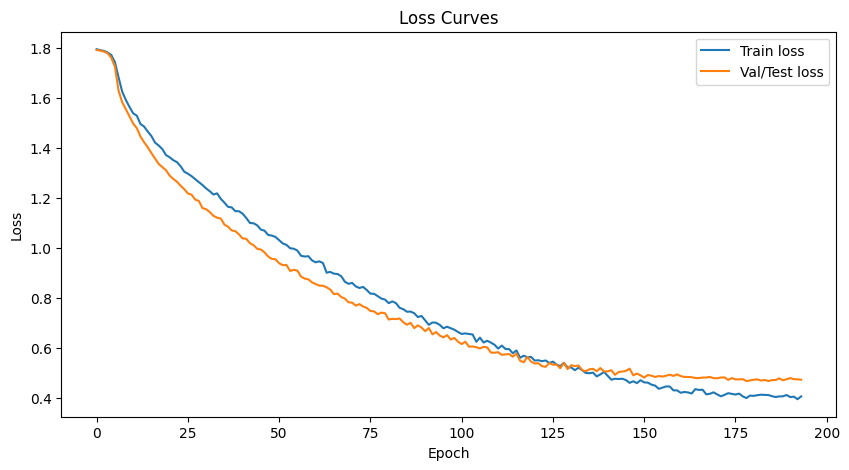

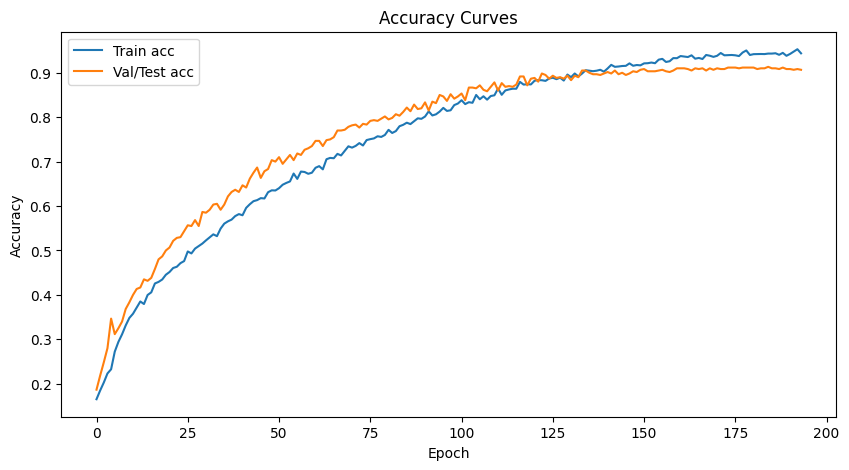

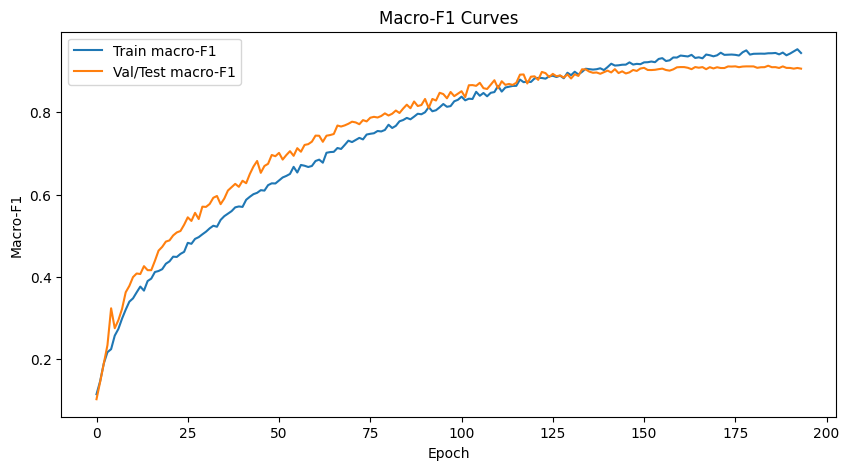

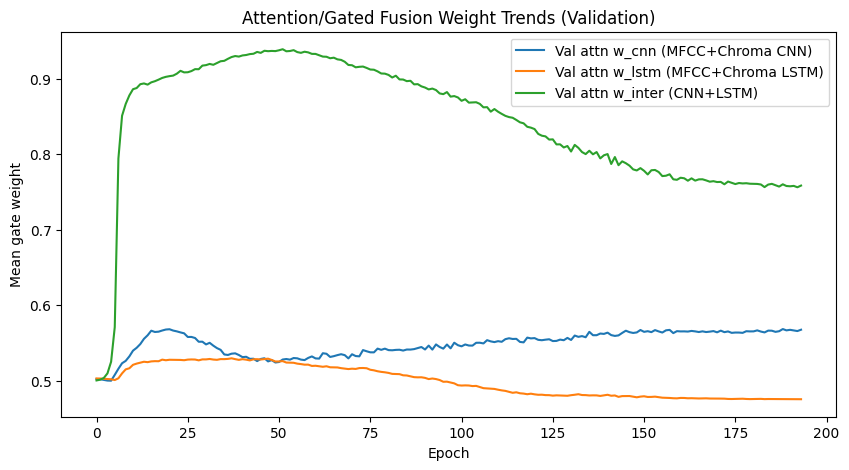

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Val/Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curves")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_acc"], label="Train acc")
plt.plot(history["val_acc"], label="Val/Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curves")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_f1"], label="Train macro-F1")
plt.plot(history["val_f1"], label="Val/Test macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.title("Macro-F1 Curves")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["val_w_cnn"], label="Val attn w_cnn (MFCC+Chroma CNN)")
plt.plot(history["val_w_lstm"], label="Val attn w_lstm (MFCC+Chroma LSTM)")
plt.plot(history["val_w_inter"], label="Val attn w_inter (CNN+LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Mean gate weight")
plt.legend()
plt.title("Attention/Gated Fusion Weight Trends (Validation)")
plt.show()


## 10) Final Evaluation on Unseen Set (Confusion Matrix + Report)
Loads the best checkpoint (lowest validation loss) and evaluates on the unseen set.

Unseen Accuracy: 0.6973
Unseen Macro Precision: 0.7130 | Recall: 0.6973 | F1: 0.6975

Classification report:
              precision    recall  f1-score   support

           0     0.8300    0.7520    0.7891       500
           1     0.8080    0.5220    0.6343       500
           2     0.6737    0.8300    0.7437       500
           3     0.6301    0.6780    0.6532       500
           4     0.7963    0.7660    0.7808       500
           5     0.5399    0.6360    0.5840       500

    accuracy                         0.6973      3000
   macro avg     0.7130    0.6973    0.6975      3000
weighted avg     0.7130    0.6973    0.6975      3000



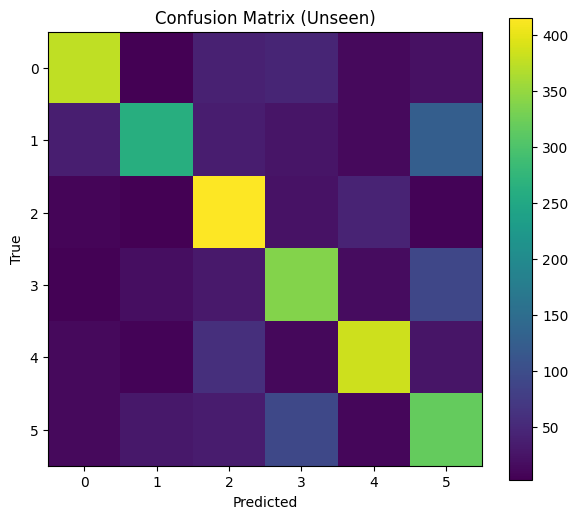

In [17]:
# Load best checkpoint
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for mfcc, chroma, y in unseen_loader:
        mfcc = mfcc.to(device)
        chroma = chroma.to(device)
        logits = model(mfcc, chroma)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

acc = accuracy_score(all_targets, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average="macro", zero_division=0)
print(f"Unseen Accuracy: {acc:.4f}")
print(f"Unseen Macro Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

print("\nClassification report:")
print(classification_report(all_targets, all_preds, digits=4))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Unseen)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()